In [1]:
from matplotlib import pyplot as plt
import matplotlib
import numpy as np
from Full_Par_Method import FidPars
from numpy.random import normal

In [2]:
FidPars

{'psi0': -2.5,
 'm0': 11.5,
 'mass_norm': 8.3,
 'scatter': 0.45,
 'tau': 5.55,
 'gamma_inner': -0.75}

GSMF

In [3]:
psi0 = FidPars['psi0']
m0 = FidPars['m0']

In [4]:
def GSMF(M):
    return np.log(10)*10**psi0*(M/10**m0)**0.25*np.exp(-M/10**m0)

In [5]:
ms = np.logspace(0,13)

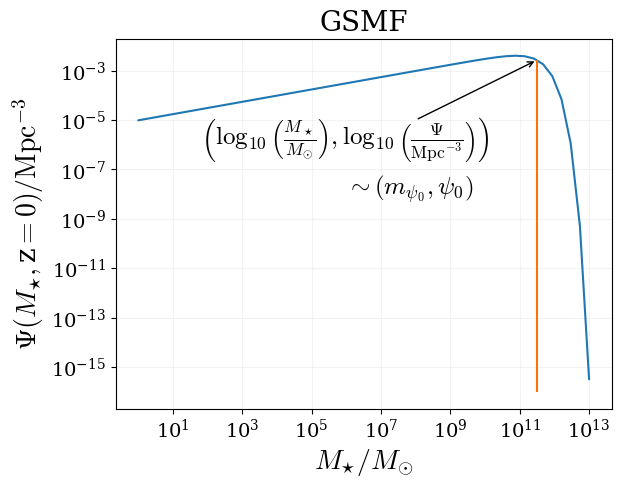

In [6]:
fig, ax = plt.subplots()
ax.plot(ms,GSMF(ms))
plt.title('GSMF', fontsize = 20)
ax.set_xlabel('$M_{\\star}/M_{\\odot}$', fontsize=20)
ax.set_ylabel('$\\Psi(M_{\\star},$z$ = 0)/\\mathrm{Mpc}^{-3}$', fontsize=20)
ax.annotate('',xytext=(1e8,1e-5),xy=(10**m0,GSMF(10**m0)),arrowprops=dict(arrowstyle="->"))
ax.annotate('$\\left(\\log_{10}\\left(\\frac{M_\\star}{M_{\\odot}}\\right),\\log_{10}\\left(\\frac{\\Psi}{\\mathrm{Mpc}^{-3}}\\right)\\right)$',xytext=(10**1.8,1e-6), xy=(1e10,1e-4),fontsize=18)
ax.annotate('$\\sim (m_{\\psi_0},\\psi_0)$',xytext=(10**6,1e-8), xy=(1e10,1e-4),fontsize=18)
ax.vlines(10**m0, 1e-16, GSMF(10**m0), color='xkcd:orange')
ax.tick_params(labelsize=14)
ax.set_xscale('log')
ax.set_yscale('log')
plt.savefig('GSMF-FidPars.png', bbox_inches='tight')

In [7]:
mu = FidPars['mass_norm']
eps = FidPars['scatter']

In [8]:
def MBHMBulge(M, eps = 0):
    try:
        s = normal(0,eps,len(M))
    except:
        s = normal(0,eps, 1)
    return mu + M + s - 11

In [9]:
M = np.linspace(5,15)

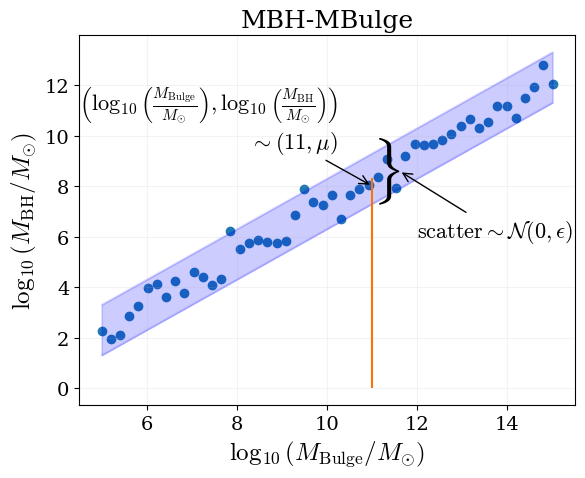

In [11]:
fig, ax = plt.subplots()
plt.title('MBH-MBulge', fontsize = 18)
ax.set_ylabel('$\\log_{10}(M_{\\mathrm{BH}}/M_{\\odot})$', fontsize= 18)
ax.set_xlabel('$\\log_{10}(M_{\\mathrm{Bulge}}/M_{\\odot})$', fontsize= 18)
braket = ax.annotate(r"$\}$",fontsize=18,
            xytext=(11, MBHMBulge(11)-0.5), xy = (11, MBHMBulge(11)-2.5))
braket.set_fontsize(40)
arrow = ax.annotate('$\\mathrm{scatter} \\sim \\mathcal{N}(0,\\epsilon)$',xytext=(12,6),xy=(11.6, MBHMBulge(11)+0.3),arrowprops=dict(arrowstyle="->"))
arrow.set_fontsize(16)
ax.annotate('$\\left(\\log_{10}\\left(\\frac{M_{\\mathrm{Bulge}}}{M_{\\odot}}\\right),\\log_{10}\\left(\\frac{M_{\\mathrm{BH}}}{M_{\\odot}}\\right)\\right)$', xy = (11,8), xytext = (4.5,11), fontsize = 16)
ax.annotate('$\\sim (11, \\mu)$', xy = (11,8), xytext = (8.3,9.5), arrowprops=dict(arrowstyle="->"), fontsize = 16)
ax.scatter(M,MBHMBulge(M, eps = eps))
ax.plot(M,MBHMBulge(M) + 1, alpha = 0.1,color= 'blue')
ax.plot(M,MBHMBulge(M) - 1, alpha = 0.1, color = 'blue')
ax.vlines(11,0,MBHMBulge(11), color='xkcd:orange')
ax.tick_params(labelsize=14)
ax.fill_between(M,y1= MBHMBulge(M) + 1,y2= MBHMBulge(M) -1,color='blue', alpha=.2)
plt.savefig('MBH-MBulge-FidPars.png', bbox_inches='tight')

In [13]:
aisco = 0.2
aout = 2
ac = 1.25
thet = np.linspace(0,2*np.pi)
x1 = aisco*np.cos(thet)
y1 = aisco*np.sin(thet)
x2 = aout*np.cos(thet)
y2 = aout*np.sin(thet)
x3 = ac*np.cos(thet)
y3 = ac*np.sin(thet)

In [14]:
def Orbit(angle, radius):
    x = radius*np.cos(angle)
    y = radius*np.sin(angle)
    return x,y

In [15]:
x1, y1 = Orbit(thet, aisco)
x2, y2 = Orbit(thet, aout)
x3, y3 = Orbit(thet, ac)

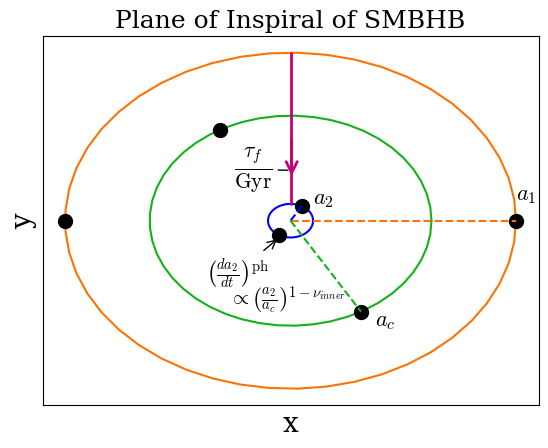

In [24]:
fig, ax = plt.subplots()
plt.title('Plane of Inspiral of SMBHB', fontsize = 18)
ax.set_xlabel('x', fontsize = 20)
ax.set_ylabel('y', fontsize = 20)
ax.scatter(Orbit(np.pi/3,aisco)[0],Orbit(np.pi/3,aisco)[1], s = 100, color = 'black', zorder = 1)
ax.scatter(-Orbit(np.pi/3,aisco)[0],-Orbit(np.pi/3,aisco)[1], s = 100, color = 'black', zorder = 1)
ax.scatter(Orbit(3*np.pi/3,aout)[0],Orbit(3*np.pi/3,aout)[1], s = 100, color = 'black', zorder = 1)
ax.scatter(-Orbit(3*np.pi/3,aout)[0],-Orbit(3*np.pi/3,aout)[1], s = 100, color = 'black', zorder = 1)
ax.scatter(Orbit(2*np.pi/3,ac)[0],Orbit(2*np.pi/3,ac)[1], s = 100, color = 'black', zorder = 1)
ax.scatter(-Orbit(2*np.pi/3,ac)[0],-Orbit(2*np.pi/3,ac)[1], s = 100, color = 'black', zorder = 1)
ax.annotate('$a_2$', xy = (0.2,0.2), fontsize = 16)
plt.plot((0,Orbit(np.pi/3,aisco)[0]),(0,Orbit(np.pi/3,aisco)[1]), linestyle = '--', color= 'blue')
ax.annotate('$a_1$', xy = (2,0.25), fontsize = 16)
plt.plot((0,Orbit(0,aout)[0]),(0,Orbit(0,aout)[1]), linestyle = '--', color= 'xkcd:orange')
ax.annotate('$a_c$', xy = (0.75,-1.25), fontsize = 16)
plt.plot((0,-Orbit(2*np.pi/3,ac)[0]),(0,-Orbit(2*np.pi/3,ac)[1]), linestyle = '--', color= 'xkcd:green')
ax.plot(x1,y1, color='blue', zorder = 0)
ax.plot(x2,y2, color='xkcd:orange',zorder = 0)
ax.plot(x3,y3, color='xkcd:green', zorder = 0)
ax.annotate('$\\left(\\frac{da_2}{dt}\\right)^{\\text{ph}}$', xytext = (-0.75,-0.69), xy = (-0.1,-0.2),arrowprops=dict(arrowstyle="->"), fontsize = 15)
ax.annotate('$\\propto \\left(\\frac{a_2}{a_c}\\right)^{1-\\nu_{inner}}$', xy = (-0.55,-1), fontsize = 15)
ax.plot((0,0),(aisco,aout), color = 'xkcd:magenta', linewidth = 2)
ax.annotate('',xytext = (0.01,1), xy = (0.01,0.5), arrowprops=dict(arrowstyle="->", color = 'xkcd:magenta', linewidth = 2), fontsize=20)
ax.annotate('$\\frac{\\tau_{f}}{\\mathrm{Gyr}}$', xytext = (-0.5,0.55), xy= (0,0.6), arrowprops=dict(arrowstyle="-"), fontsize = 22)
ax.tick_params(labelsize=14)
plt.xticks([])
plt.yticks([])
plt.savefig('Hardening-FidPars.png', bbox_inches='tight')